In [3]:
import sys
sys.path.append('../')

import os
import json
import cirq
import numpy as np
from copy import deepcopy
from natsort import natsorted
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import gmean
from scipy import linalg
from phoenix.synthesis import grouping, ordering
from phoenix.models import HamiltonianModel, Clifford2Q, BSF
from phoenix.synthesis.simplification import simplify_bsf, search_cliffords
from phoenix import Circuit
from phoenix import models
from phoenix.utils import passes, ops
from qiskit import QuantumCircuit
from qiskit.circuit.library import PauliEvolutionGate

from qiskit.quantum_info import Operator
import qiskit.quantum_info as qi



In [102]:
class MultiPauliRotation(cirq.Gate):
    """Use universal controlled gates to represent generic 2Q Clifford gates"""

    def __init__(self, pauli: str, time: float):
        super(MultiPauliRotation, self)
        self.pauli = pauli
        self.time = time

    def _num_qubits_(self):
        return len(self.pauli) - self.pauli.count('I')

    def _unitary_(self):
        import qiskit.quantum_info as qi
        return linalg.expm(-1j * qi.SparsePauliOp([self.pauli], [self.time]).to_matrix())

    def _circuit_diagram_info_(self, args):
        # return [f"C({self.pauli_0}, {self.pauli_1})"] * self.num_qubits()
        if self.time is None:
            if self._num_qubits_() == 1:
                return ['R{}'.format(p.lower()) for p in self.pauli if p != 'I']
            return [p for p in self.pauli if p != 'I']
        angle_str = '{:.1f}'.format(self.time * 2)
        return [p + '({})'.format(angle_str) for p in self.pauli if p != 'I']


class CirqClifford2QGate(cirq.Gate):
    """Use universal controlled gates to represent generic 2Q Clifford gates"""

    def __init__(self, pauli_0: str, pauli_1: str):
        super(CirqClifford2QGate, self)
        assert pauli_0 in ['X', 'Y', 'Z'] and pauli_1 in ['X', 'Y', 'Z']
        self.pauli_0, self.pauli_1 = pauli_0, pauli_1

    def _num_qubits_(self):
        return 2

    def _unitary_(self):
        import qiskit.quantum_info as qi
        I = qi.Pauli('I')
        P0, P1 = qi.Pauli(self.pauli_0), qi.Pauli(self.pauli_1)
        return qi.SparsePauliOp([I ^ I, P0 ^ I, I ^ P1, P0 ^ P1],
                                [1 / 2, 1 / 2, 1 / 2, -1 / 2]).to_matrix()

    def _circuit_diagram_info_(self, args):
        return [f"C{self.pauli_0.lower()}{self.pauli_1.lower()}"] * self.num_qubits()



In [30]:
circ = cirq.Circuit()
QUBITS = cirq.LineQubit.range(10)
circ.append(MultiPauliRotation('XXX', 0.1).on(*QUBITS[0:3]))
circ

0: ───X(0.2)───
      │
1: ───X(0.2)───
      │
2: ───X(0.2)───

In [37]:
paulis, coeffs = ['XXXZYZ', 'YXXZYY', 'ZXXZYZ'], np.array([0.1, 0.2, 0.3])
ham = HamiltonianModel(paulis, coeffs)

In [38]:
ham.pauli_sum()

SparsePauliOp(['XXXZYZ', 'YXXZYY', 'ZXXZYZ'],
              coeffs=[0.1+0.j, 0.2+0.j, 0.3+0.j])

In [39]:
def hamiltonian_to_qiskit(ham: HamiltonianModel):
    qc = QuantumCircuit(ham.num_qubits)
    for pauli, coeff in zip(ham.paulis, ham.coeffs):
        qc.append(PauliEvolutionGate(qi.SparsePauliOp(pauli), time=coeff), range(ham.num_qubits))
    return qc

def hamiltonian_to_cirq(ham: HamiltonianModel):
    circ = cirq.Circuit()
    qubits = cirq.LineQubit.range(ham.num_qubits)
    for pauli, coeff in zip(ham.paulis, ham.coeffs):
        qubits_acted = [qubits[i] for i in range(len(pauli)) if pauli[i] != 'I']
        circ.append(MultiPauliRotation(pauli, coeff).on(*qubits_acted))
    return circ

In [40]:
hamiltonian_to_cirq(ham)

0: ───X(0.2)───Y(0.4)───Z(0.6)───
      │        │        │
1: ───X(0.2)───X(0.4)───X(0.6)───
      │        │        │
2: ───X(0.2)───X(0.4)───X(0.6)───
      │        │        │
3: ───Z(0.2)───Z(0.4)───Z(0.6)───
      │        │        │
4: ───Y(0.2)───Y(0.4)───Y(0.6)───
      │        │        │
5: ───Z(0.2)───Y(0.4)───Z(0.6)───

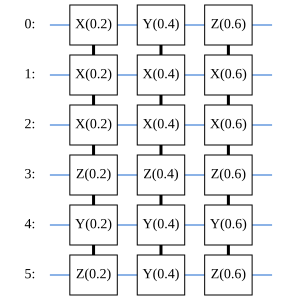

In [43]:
from cirq.contrib.svg import SVGCircuit

SVGCircuit(hamiltonian_to_cirq(ham))

In [14]:
hamiltonian_to_qiskit(ham).draw(fold=200)


┌───────────────────────┐┌───────────────────────┐┌───────────────────────┐
q_0: ┤0                      ├┤0                      ├┤0                      ├
     │                       ││                       ││                       │
q_1: ┤1                      ├┤1                      ├┤1                      ├
     │                       ││                       ││                       │
q_2: ┤2                      ├┤2                      ├┤2                      ├
     │  exp(-it XXXZYZ)(0.1) ││  exp(-it YXXZYY)(0.2) ││  exp(-it ZXXZYZ)(0.3) │
q_3: ┤3                      ├┤3                      ├┤3                      ├
     │                       ││                       ││                       │
q_4: ┤4                      ├┤4                      ├┤4                      ├
     │                       ││                       ││                       │
q_5: ┤5                      ├┤5                      ├┤5                      ├
     └───────────────────────┘└───────────────────────┘└───────────────────────┘

In [16]:
config = []
bsf = BSF(paulis, coeffs)

# bsf_, cliffords_with_locals = simplify_bsf(bsf)  # ! simplify the BSF


bsf = deepcopy(bsf)
cliffords_with_locals = []
avoid = None

# print(hamiltonian_to_qiskit(HamiltonianModel(bsf.paulis, bsf.coeffs)).draw(fold=200))
print(hamiltonian_to_cirq(HamiltonianModel(bsf.paulis, bsf.coeffs)))
circ_left = cirq.Circuit()
circ_right = cirq.Circuit()
while bsf.total_weight > 2:
    print('---'*20)
    local_bsf = bsf.pop_local_paulis()
    if local_bsf.num_paulis > 0:
        print('popped local paulis: {}'.format(local_bsf.paulis))
    t, c, cliff = search_cliffords(bsf, avoid)
    print('Searched clifford: {}, Now cost: {:.2f}'.format(cliff, c))
    circ_left.append(CirqClifford2QGate(cliff.pauli_0, cliff.pauli_1).on(QUBITS[cliff.ctrl], QUBITS[cliff.targ]))
    circ_right.insert(0, CirqClifford2QGate(cliff.pauli_0, cliff.pauli_1).on(QUBITS[cliff.ctrl], QUBITS[cliff.targ]))

    avoid = cliff.ctrl, cliff.targ
    # cliffords_with_locals.append((cliff, list(zip(local_paulis, local_coeffs))))
    cliffords_with_locals.append((cliff, local_bsf))
    # console.print('applied {} --> {} cost: {} (is_simplified: {})'.format(cliff, t.paulilist, c, t.total_weight <= 2))
    bsf = t
    # print(hamiltonian_to_qiskit(HamiltonianModel(bsf.paulis, bsf.coeffs)).draw(fold=200))
    print(circ_left + hamiltonian_to_cirq(HamiltonianModel(bsf.paulis, bsf.coeffs)) + circ_right)


# console.print('Now BSF: {}, cliff_with_locals: {}'.format(bsf, cliffords_with_locals))







    # if cliffords_with_locals:  # because it might be an empty list
    #     post_cliffs_with_locals = [[cliff, local_bfs] if local_bfs.num_paulis > 0 else [cliff] for
    #                                 cliff, local_bfs
    #                                 in reversed(cliffords_with_locals)]
    #     res.extend([cliff for cliff, _ in cliffords_with_locals])  # pre-cliffs
    #     res.append(bsf_)
    #     res.extend([item for sublist in post_cliffs_with_locals for item in sublist])
    # else:
    #     res.append(bsf_)

    # config.extend(res)

print('---'*20)

0: ───X(0.2)───Y(0.4)───Z(0.6)───
      │        │        │
1: ───X(0.2)───X(0.4)───X(0.6)───
      │        │        │
2: ───X(0.2)───X(0.4)───X(0.6)───
      │        │        │
3: ───Z(0.2)───Z(0.4)───Z(0.6)───
      │        │        │
4: ───Y(0.2)───Y(0.4)───Y(0.6)───
      │        │        │
5: ───Z(0.2)───Y(0.4)───Z(0.6)───
------------------------------------------------------------
Searched clifford: C(X, Y) @ (3, 4), Now cost: 70.00
0: ─────────X(0.2)───Y(0.4)───Z(0.6)─────────
            │        │        │
1: ─────────X(0.2)───X(0.4)───X(0.6)─────────
            │        │        │
2: ─────────X(0.2)───X(0.4)───X(0.6)─────────
            │        │        │
3: ───Cxy───Z(0.2)───Z(0.4)───Z(0.6)───Cxy───
      │     │        │        │        │
4: ───Cxy───┼────────┼────────┼────────Cxy───
            │        │        │
5: ─────────Z(0.2)───Y(0.4)───Z(0.6)─────────
------------------------------------------------------------
Searched clifford: C(X, X) @ (1, 3), Now cost:

In [22]:
QUBITS

[cirq.LineQubit(0),
 cirq.LineQubit(1),
 cirq.LineQubit(2),
 cirq.LineQubit(3),
 cirq.LineQubit(4),
 cirq.LineQubit(5),
 cirq.LineQubit(6),
 cirq.LineQubit(7),
 cirq.LineQubit(8),
 cirq.LineQubit(9)]

In [69]:
paulis = ['ZYZZ', 'XZZY', 'ZYXY', 'ZIYX', 'ZXIY', 'IZYX', 'XXXY', 'XYXI', 'YIXX', 'XZYY', 'ZZIZ', 'YXXI']
coeffs = [None] * len(paulis)
circ = cirq.Circuit()
qubits = cirq.LineQubit.range(ham.num_qubits)
for pauli, coeff in zip(paulis, coeffs):
    qubits_acted = [qubits[i] for i in range(len(pauli)) if pauli[i] != 'I']
    circ.append(MultiPauliRotation(pauli, coeff).on(*qubits_acted))



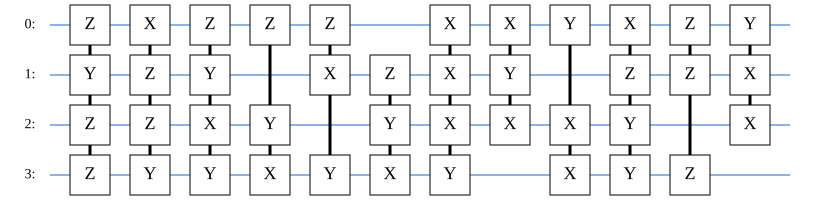

In [70]:
from cirq.contrib.svg import SVGCircuit

SVGCircuit(circ)

In [ ]:
grouped_circ = cirq.Circuit()
for idx, paulis_part in grouping.group_paulis(paulis).items():
    subcircuit = cirq.Circuit()
    qubits_acted = [QUBITS[i] for i in idx]
    subcircuit = cirq.Circuit([MultiPauliRotation(pauli, None).on(*qubits_acted) for pauli in paulis_part])
    grouped_circ += subcircuit

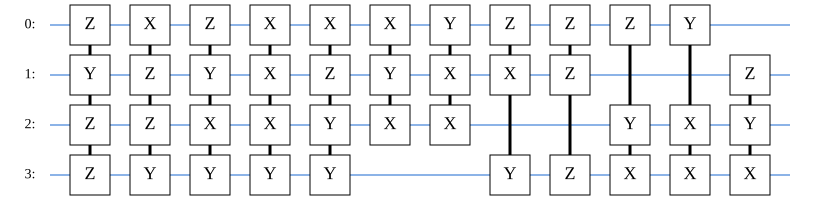

In [74]:
SVGCircuit(grouped_circ)

In [67]:
grouping.group_paulis(paulis)

{(0, 1, 2, 3): ['ZYZZ', 'XZZY', 'ZYXY', 'XXXY', 'XZYY'],
 (0, 1, 2): ['XYXI', 'YXXI'],
 (0, 1, 3): ['ZXIY', 'ZZIZ'],
 (0, 2, 3): ['ZIYX', 'YIXX'],
 (1, 2, 3): ['IZYX']}

In [77]:
print(paulis)

['ZYZZ', 'XZZY', 'ZYXY', 'ZIYX', 'ZXIY', 'IZYX', 'XXXY', 'XYXI', 'YIXX', 'XZYY', 'ZZIZ', 'YXXI']


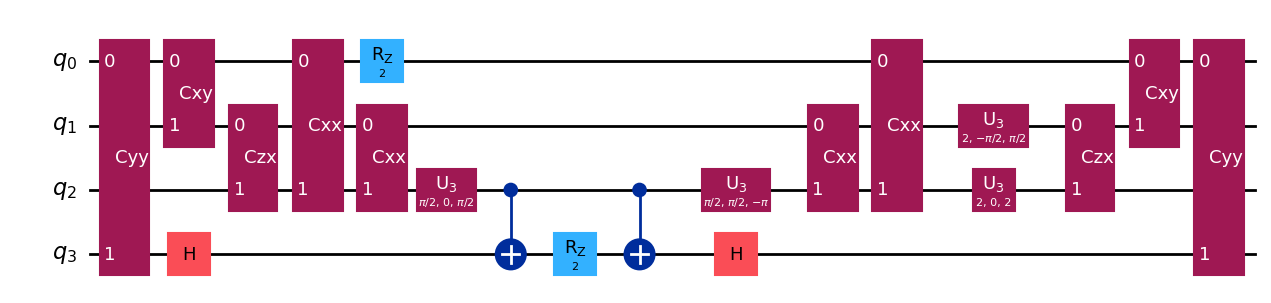

In [103]:
subcircuits_simplified = []
for idx, paulis_part in grouping.group_paulis(paulis).items():
    ham = HamiltonianModel(paulis_part, np.ones(len(paulis_part)))
    circ = ham.phoenix_circuit()
    subcircuits_simplified.append(circ)
subcircuits_simplified[0].to_qiskit().draw('mpl', fold=200)

In [108]:
def draw_circuit(circ: Circuit):
    c = cirq.Circuit()


configs = HamiltonianModel(paulis, coeffs).phoenix_reconfigure()
subcircuits_simplified = []
for config in configs:
    circ = cirq.Circuit()
    for item in config:
        if isinstance(item, Clifford2Q):
            circ.append(CirqClifford2QGate(item.pauli_0, item.pauli_1).on(QUBITS[item.ctrl], QUBITS[item.targ]))
        elif isinstance(item, BSF):
            for pauli, coeff in zip(item.paulis, item.coeffs):
                qubits_acted = [QUBITS[i] for i in range(len(pauli)) if pauli[i] != 'I']
                circ.append(MultiPauliRotation(pauli, coeff).on(*qubits_acted))
    subcircuits_simplified.append(circ)




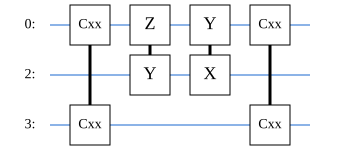

In [118]:
SVGCircuit(subcircuits_simplified[3])

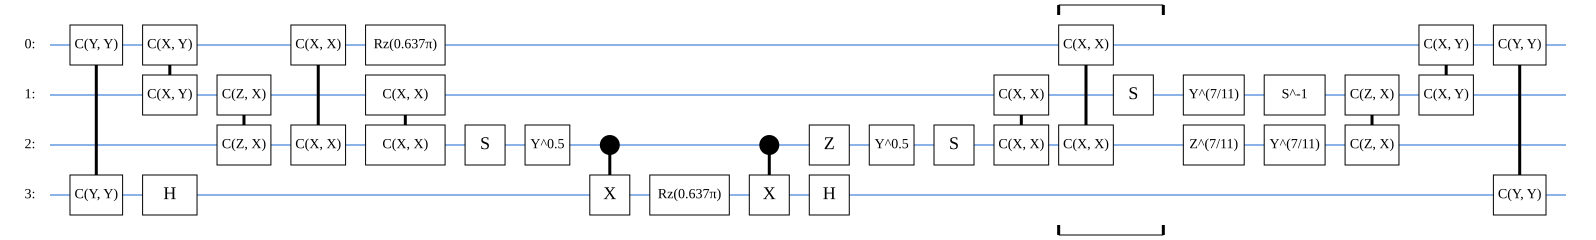

In [90]:
SVGCircuit(subcircuits_simplified[0].to_cirq())

In [93]:
ham.phoenix_reconfigure()

[[C(Y, Y) @ (0, 3),
  C(X, Y) @ (0, 1),
  C(Z, X) @ (1, 2),
  C(X, X) @ (0, 2),
  C(X, X) @ (1, 2),
  BSF(size=[1, 4], num_nonlocals=1, total_weight=2),
  C(X, X) @ (1, 2),
  BSF(size=[1, 4], num_nonlocals=0, total_weight=1),
  C(X, X) @ (0, 2),
  BSF(size=[3, 4], num_nonlocals=0, total_weight=1),
  C(Z, X) @ (1, 2),
  C(X, Y) @ (0, 1),
  C(Y, Y) @ (0, 3)]]

In [ ]:
['ZYZZ', 'XZZY', 'ZYXY', 'ZIYX', 
 'ZXIY', 'IZYX', 'XXXY', 'XYXI', 
 'YIXX', 'XZYY', 'ZZIZ', 'YXXI']

In [86]:
u2 = np.eye(2**ham.num_qubits, dtype=complex)
for pauli, coeff in zip(paulis, coeffs):
    u2 = linalg.expm(-1j * qi.SparsePauliOp(pauli, coeff).to_matrix()) @ u2

u2 = ham.unitary_evolution()

In [90]:
ops.is_equiv_unitary(u1, u2)

False

In [88]:
u1[0]

array([ 0.54030231+0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,
        0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,
        0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,
        0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,
        0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,
        0.        +0.j,  0.        +0.j,  0.        +0.j, -0.84147098+0.j,
        0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,
        0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,
        0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,
        0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,
        0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,
        0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,
        0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,
        0.        +0.j,  

In [89]:
u2[0]

array([ 0.54030231+0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,
        0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,
        0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,
        0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,
        0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,
        0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,
        0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,
        0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,
        0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,
        0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,
        0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,
        0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,
        0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,
        0.        +0.j,  

In [32]:
qi.SparsePauliOp('-XXX')

SparsePauliOp(['XXX'],
              coeffs=[-1.+0.j])

In [21]:
u2[0]

array([ 9.99765642e-01+0.j, -1.56237793e-04+0.j,  0.00000000e+00+0.j,
        0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
        0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
        0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
        0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
        0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
        0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
        0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
        0.00000000e+00+0.j,  0.00000000e+00+0.j,  1.24983725e-02+0.j,
        4.56536396e-23+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
        0.00000000e+00+0.j,  0.00000000e+00+0.j, -6.79389616e-25+0.j,
        1.56237793e-04+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
        0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
        0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
        0.00000000e+